In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

BASE_DIR = Path.cwd().parent
RESULTS_DIR = BASE_DIR / 'results'

In [3]:
def get_df(name):
    csv_path = RESULTS_DIR / f'{name}.csv'

    if not csv_path.exists():
        raise FileNotFoundError(f'Nie znaleziono pliku {csv_path}')
    
    meta_df = pd.read_csv(csv_path, nrows=1)
    metadata = meta_df.iloc[0].to_dict()

    df = pd.read_csv(csv_path, skiprows=2)
        
    return df, metadata

In [ ]:
def show_heatmaps(df_name,
                  values='average_value_top_80',
                  vmin=1e-6,
                  vmax=1):
    df, metadata = get_df(df_name)
    
    function = metadata['objective']
    dim = int(metadata['dimensionality'])
    pop_size = metadata.get('population_size', 'N/A')
    num_iters = metadata.get('num_iterations', 'N/A')

    selections = sorted(df['selection'].unique())
    crossovers = sorted(df['crossover'].unique())
    mutations = sorted(df['mutation'].unique())

    axes_width = len(selections) * len(crossovers) * len(mutations)

    fig, axes = plt.subplots(1, axes_width,
                             figsize=(5 * axes_width, 5),
                             constrained_layout=True)

    if axes_width == 1:
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()

    h_index = 0
    for selection in selections:
        for crossover in crossovers:
            for mutation in mutations:
                ax = axes[h_index]

                df_fixed = df[(df['selection'] == selection)
                            & (df['crossover'] == crossover)
                            & (df['mutation'] == mutation)]

                heatmap_data = df_fixed.pivot(index='mutation_prob',
                                              columns='crossover_prob',
                                              values=values)[::-1]

                heatmap_data = heatmap_data.clip(lower=vmin, upper=vmax)
                heatmap_data.index = heatmap_data.index.astype(float).round(3)
                heatmap_data.columns = heatmap_data.columns.astype(float).round(3)

                sns.heatmap(
                    heatmap_data,
                    annot=False,
                    cmap='plasma',
                    ax=ax,
                    norm=LogNorm(vmin=vmin, vmax=vmax),
                    cbar=False
                )

                ax.set_title(f'Selection: {selection}\nCrossover: {crossover}\nMutation: {mutation}', fontsize=10)

                if h_index == 0:
                    ax.set_ylabel(
                        f'Objective: {function}\n'
                        f'Dimensionality: {dim}\n'
                        f'Pop Size: {pop_size} | Iters: {num_iters}\n\n'
                        f'Mutation Probability', fontsize=11
                    )
                else:
                    ax.set_ylabel('')

                ax.set_xlabel('Crossover Probability', fontsize=10)
                h_index += 1

    sm = ScalarMappable(norm=LogNorm(vmin=vmin, vmax=vmax), cmap='plasma')
    sm.set_array([])
    fig.colorbar(sm, ax=axes, fraction=0.02, pad=0.02)
    
    plt.show()

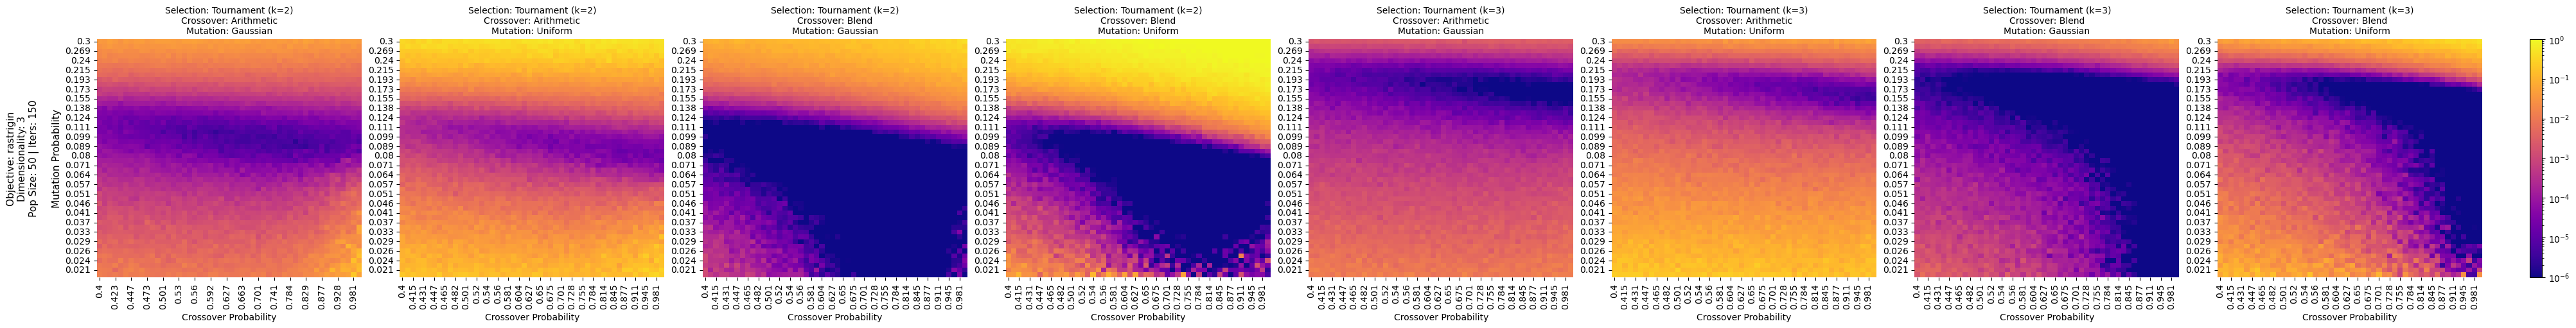

In [4]:
show_heatmaps('SGA_results_benchmark_20260726_095549')